In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/riatalsania0510/adni-shortened/shortened_result-val.csv


In [2]:
# ── Suppress noisy warnings ──────────────────────────────────────────────
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # hide TF logs

# ── Core ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)

# ── TensorFlow / Keras ───────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# ── GPU Setup (Kaggle-friendly) ──────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ {len(gpus)} GPU(s) detected — using GPU")
    except:
        print("⚠️ GPU detected but memory growth setup failed")
else:
    print("ℹ️ No GPU detected — using CPU")

# ── Reproducibility ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Plot style ───────────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Sliding Window Helper (VERY IMPORTANT for next steps) ────────────────
def create_sliding_windows(data, target_col, window_size=3, stride=1):
    """
    Converts longitudinal data into LSTM-ready sliding windows.

    Args:
        data (pd.DataFrame): sorted by subject + time
        target_col (str): column to predict
        window_size (int): number of timesteps in input
        stride (int): step size

    Returns:
        X (np.array): shape (samples, window_size, features)
        y (np.array): shape (samples,)
    """
    X, y = [], []

    for i in range(0, len(data) - window_size, stride):
        window = data.iloc[i:i+window_size]
        target = data.iloc[i+window_size][target_col]

        X.append(window.drop(columns=[target_col]).values)
        y.append(target)

    return np.array(X), np.array(y)

print("✅ Setup complete — ready for sliding window training")

2026-04-23 07:59:02.702672: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776931142.945067      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776931143.014688      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776931143.558925      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776931143.558975      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776931143.558978      23 computation_placer.cc:177] computation placer alr

✅ 2 GPU(s) detected — using GPU
✅ Setup complete — ready for sliding window training


In [3]:
df = pd.read_csv('/kaggle/input/datasets/riatalsania0510/adni-shortened/shortened_result-val.csv')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

df.head()

Shape: (22168, 12)
Columns: ['subject_id', 'visit', 'entry_age', 'CDGLOBAL', 'MMSCORE', 'DIAGNOSIS', 'TOTSCORE', 'num_visits', 'num_dirty_rows', 'num_dirty_mmse', 'num_dirty_cdglobal', 'num_dirty_totscore']


,subject_id,visit,entry_age,CDGLOBAL,MMSCORE,DIAGNOSIS,TOTSCORE,num_visits,num_dirty_rows,num_dirty_mmse,num_dirty_cdglobal,num_dirty_totscore
0,941_S_10002,bl,72.95,NaN,NaN,2.0,9.00,4,2,1,1,1
1,941_S_10002,m12,72.95,0.5,24.0,2.0,2.33,4,2,1,1,1
2,941_S_10002,m24,72.95,0.5,24.0,2.0,5.00,4,2,1,1,1
3,941_S_10002,sc,72.95,0.5,27.0,2.0,NaN,4,2,1,1,1
4,941_S_7074,bl,70.90,NaN,NaN,1.0,3.00,5,3,2,2,2


In [4]:
# ── Unique values ───────────────────────────────────────────────────────
print("Total unique subjects:", df['subject_id'].nunique())

print("\nUnique visit values:")
print(sorted(df['visit'].dropna().unique()))

Total unique subjects: 3034

Unique visit values:
['AUT', 'bl', 'm03', 'm06', 'm102', 'm108', 'm114', 'm12', 'm120', 'm126', 'm132', 'm138', 'm144', 'm150', 'm156', 'm162', 'm168', 'm174', 'm18', 'm180', 'm186', 'm192', 'm198', 'm204', 'm210', 'm216', 'm222', 'm228', 'm234', 'm24', 'm240', 'm30', 'm36', 'm42', 'm48', 'm54', 'm60', 'm66', 'm72', 'm78', 'm84', 'm90', 'm96', 'nv', 'sc', 'scmri', 'uns1']


In [5]:
# Convert 1,2,3 → 0,1,2
df['DIAGNOSIS'] = df['DIAGNOSIS'].astype(int) - 1

# VERIFY (VERY IMPORTANT)
print("Unique DIAGNOSIS:", np.unique(df['DIAGNOSIS']))

Unique DIAGNOSIS: [0 1 2]


In [6]:
# ── Filter bl + sc ──────────────────────────────────────────────────────
df_bl_sc = df[df['visit'].isin(['bl', 'sc'])].copy()

# ── Pivot ───────────────────────────────────────────────────────────────
pivot = df_bl_sc.pivot_table(
    index='subject_id',
    columns='visit',
    values=['MMSCORE', 'TOTSCORE', 'CDGLOBAL'],
    aggfunc='first'
)

# Flatten columns
pivot.columns = ['_'.join(col) for col in pivot.columns]

# 🔥 Ensure all expected columns exist (VERY IMPORTANT)
expected_cols = [
    'MMSCORE_bl', 'MMSCORE_sc',
    'TOTSCORE_bl', 'TOTSCORE_sc',
    'CDGLOBAL_bl', 'CDGLOBAL_sc'
]

for col in expected_cols:
    if col not in pivot.columns:
        pivot[col] = np.nan

pivot = pivot.reset_index()

# ── Condition: one missing, other present ────────────────────────────────
condition = (
    (pivot['MMSCORE_bl'].isna() & pivot['MMSCORE_sc'].notna()) |
    (pivot['MMSCORE_sc'].isna() & pivot['MMSCORE_bl'].notna()) |
    (pivot['TOTSCORE_bl'].isna() & pivot['TOTSCORE_sc'].notna()) |
    (pivot['TOTSCORE_sc'].isna() & pivot['TOTSCORE_bl'].notna()) |
    (pivot['CDGLOBAL_bl'].isna() & pivot['CDGLOBAL_sc'].notna()) |
    (pivot['CDGLOBAL_sc'].isna() & pivot['CDGLOBAL_bl'].notna())
)

candidates = pivot[condition]

print("Total candidates:", candidates.shape[0])
candidates.head()

Total candidates: 3034


,subject_id,CDGLOBAL_sc,MMSCORE_sc,TOTSCORE_bl,MMSCORE_bl,TOTSCORE_sc,CDGLOBAL_bl
0,002_S_0295,0.0,28.0,3.00,NaN,NaN,NaN
1,002_S_0413,0.0,29.0,3.33,NaN,NaN,NaN
2,002_S_0559,0.0,30.0,6.00,NaN,NaN,NaN
3,002_S_0619,1.0,22.0,19.33,NaN,NaN,NaN
4,002_S_0685,0.0,30.0,3.67,NaN,NaN,NaN


In [7]:
candidate_ids = candidates['subject_id'].tolist()

df[df['subject_id'].isin(candidate_ids) & df['visit'].isin(['bl','sc'])]\
    .sort_values(['subject_id','visit'])\
    .head(20)

,subject_id,visit,entry_age,CDGLOBAL,MMSCORE,DIAGNOSIS,TOTSCORE,num_visits,num_dirty_rows,num_dirty_mmse,num_dirty_cdglobal,num_dirty_totscore
8024,002_S_0295,bl,84.84,NaN,NaN,0,3.00,14,7,6,6,6
8037,002_S_0295,sc,84.84,0.0,28.0,0,NaN,14,7,6,6,6
4383,002_S_0413,bl,76.34,NaN,NaN,0,3.33,24,11,10,10,10
4406,002_S_0413,sc,76.34,0.0,29.0,0,NaN,24,11,10,10,10
8770,002_S_0559,bl,79.36,NaN,NaN,0,6.00,8,4,3,3,3
8777,002_S_0559,sc,79.36,0.0,30.0,0,NaN,8,4,3,3,3
9217,002_S_0619,bl,77.46,NaN,NaN,2,19.33,6,3,2,2,2
9222,002_S_0619,sc,77.46,1.0,22.0,2,NaN,6,3,2,2,2
9530,002_S_0685,bl,89.64,NaN,NaN,0,3.67,20,14,12,9,12
9549,002_S_0685,sc,89.64,0.0,30.0,0,NaN,20,14,12,9,12


In [8]:
# ── Step 1: Separate bl and sc ──────────────────────────────────────────
df_bl = df[df['visit'] == 'bl'].copy()
df_sc = df[df['visit'] == 'sc'].copy()

# ── Step 2: Merge on subject_id ─────────────────────────────────────────
merged = pd.merge(
    df_bl,
    df_sc,
    on='subject_id',
    suffixes=('_bl', '_sc')
)

# ── Step 3: Create merged row (feature-wise combine) ────────────────────
def combine(row, col):
    val_bl = row[f"{col}_bl"]
    val_sc = row[f"{col}_sc"]
    return val_bl if pd.notna(val_bl) else val_sc

cols_to_merge = [
    'entry_age', 'CDGLOBAL', 'MMSCORE', 'TOTSCORE',
    'DIAGNOSIS', 'num_visits',
    'num_dirty_rows', 'num_dirty_mmse',
    'num_dirty_cdglobal', 'num_dirty_totscore'
]

merged_rows = []

for _, row in merged.iterrows():
    new_row = {'subject_id': row['subject_id'], 'visit': 'bl_sc'}

    for col in cols_to_merge:
        new_row[col] = combine(row, col)

    merged_rows.append(new_row)

df_bl_sc = pd.DataFrame(merged_rows)

print("Merged rows created:", df_bl_sc.shape)

Merged rows created: (2944, 12)


In [9]:
# Remove old bl and sc
df_clean = df[~df['visit'].isin(['bl', 'sc'])].copy()

# Add merged rows
df_clean = pd.concat([df_clean, df_bl_sc], ignore_index=True)

print("Final shape after merge:", df_clean.shape)

Final shape after merge: (19134, 12)


In [10]:
# Check no duplicate baseline per subject
print(df_clean[df_clean['visit'] == 'bl_sc']['subject_id'].nunique())

# Check NaNs reduced
print("\nNaNs after merge:")
print(df_clean[['MMSCORE','TOTSCORE','CDGLOBAL']].isna().sum())

2944

NaNs after merge:
MMSCORE     6653
TOTSCORE    6713
CDGLOBAL    6354
dtype: int64


In [11]:
# ── Count visits per patient ────────────────────────────────────────────
visits_per_patient = df_clean.groupby('subject_id').size()

# ── Distribution ────────────────────────────────────────────────────────
visit_counts = visits_per_patient.value_counts().sort_index()

print("Visits per patient distribution:\n")
print(visit_counts)

Visits per patient distribution:

1     641
2     307
3     182
4     190
5     295
6     183
7     265
8     172
9     125
10     90
11     97
12     74
13     73
14     56
15     51
16     54
17     61
18     29
19     23
20     24
21     12
22     11
23      9
24      5
25      1
26      3
27      1
Name: count, dtype: int64


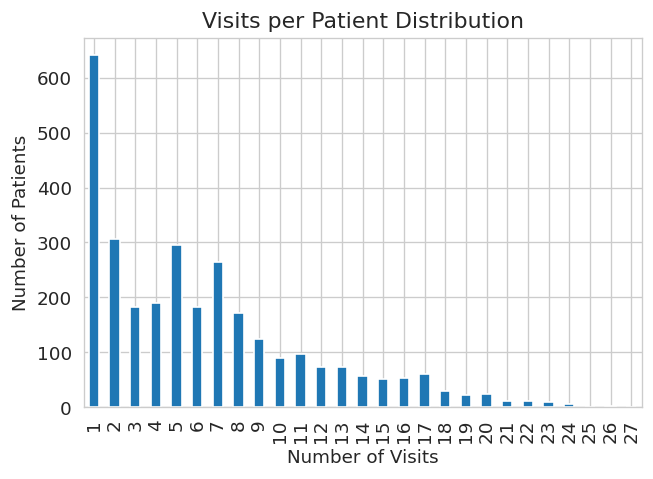

In [12]:
plt.figure(figsize=(6,4))

visit_counts.plot(kind='bar')

plt.title("Visits per Patient Distribution")
plt.xlabel("Number of Visits")
plt.ylabel("Number of Patients")
plt.grid(True)

plt.show()

In [13]:
nan_per_visit = df_clean.groupby('visit')[['MMSCORE','TOTSCORE','CDGLOBAL']]\
    .apply(lambda x: x.isna().sum())

count_per_visit = df_clean['visit'].value_counts()

summary = nan_per_visit.copy()
summary['total_rows'] = count_per_visit
summary['mmse_nan_ratio'] = summary['MMSCORE'] / summary['total_rows']
summary['tot_nan_ratio'] = summary['TOTSCORE'] / summary['total_rows']
summary['cd_nan_ratio'] = summary['CDGLOBAL'] / summary['total_rows']

summary.sort_values('total_rows', ascending=False).head(15)

,MMSCORE,TOTSCORE,CDGLOBAL,total_rows,mmse_nan_ratio,tot_nan_ratio,cd_nan_ratio
visit,,,,,,,
bl_sc,4,17,0,2944,0.001359,0.005774,0.000000
m12,356,361,349,2091,0.170253,0.172645,0.166906
m24,127,136,91,1637,0.077581,0.083079,0.055589
m06,16,19,25,1573,0.010172,0.012079,0.015893
m18,974,976,972,1312,0.742378,0.743902,0.740854
m36,237,241,239,1154,0.205373,0.208839,0.207106
scmri,976,976,976,976,1.000000,1.000000,1.000000
m48,67,71,72,888,0.075450,0.079955,0.081081
m30,771,771,766,845,0.912426,0.912426,0.906509


In [14]:
KEEP_VISITS = [
    'bl_sc', 'm06', 'm12', 'm24', 'm36',
    'm48', 'm60', 'm72', 'm84', 'm78'
]

In [15]:
df_filtered = df_clean[df_clean['visit'].isin(KEEP_VISITS)].copy()

print("Shape after filtering:", df_filtered.shape)

print("\nRemaining visits:")
print(sorted(df_filtered['visit'].unique()))

Shape after filtering: (12156, 12)

Remaining visits:
['bl_sc', 'm06', 'm12', 'm24', 'm36', 'm48', 'm60', 'm72', 'm78', 'm84']


In [16]:
def visit_to_month(v):
    if v == 'bl_sc':
        return 0
    return int(v[1:])  # m06 → 6, m12 → 12

df_filtered['visit_month'] = df_filtered['visit'].apply(visit_to_month)

# Check
print("Unique visit_month values:")
print(sorted(df_filtered['visit_month'].unique()))

Unique visit_month values:
[np.int64(0), np.int64(6), np.int64(12), np.int64(24), np.int64(36), np.int64(48), np.int64(60), np.int64(72), np.int64(78), np.int64(84)]


In [17]:
df_filtered = df_filtered.sort_values(['subject_id', 'visit_month']).reset_index(drop=True)

df_filtered.head()

,subject_id,visit,entry_age,CDGLOBAL,MMSCORE,DIAGNOSIS,TOTSCORE,num_visits,num_dirty_rows,num_dirty_mmse,num_dirty_cdglobal,num_dirty_totscore,visit_month
0,002_S_0295,bl_sc,84.84,0.0,28.0,0,3.00,14,7,6,6,6,0
1,002_S_0295,m06,84.84,0.0,28.0,0,5.33,14,7,6,6,6,6
2,002_S_0295,m12,84.84,0.0,30.0,0,4.67,14,7,6,6,6,12
3,002_S_0295,m24,84.84,0.0,29.0,0,3.67,14,7,6,6,6,24
4,002_S_0295,m36,84.84,0.0,28.0,0,3.67,14,7,6,6,6,36


In [18]:
# ── Feature Columns ─────────────────────────────────────────────────────
FEATURE_COLS = ['entry_age', 'CDGLOBAL', 'MMSCORE', 'TOTSCORE', 'visit_month']
TARGET_COL = 'DIAGNOSIS'

print("Features used:", FEATURE_COLS)

Features used: ['entry_age', 'CDGLOBAL', 'MMSCORE', 'TOTSCORE', 'visit_month']


In [19]:
unique_subjects = df_filtered['subject_id'].unique()

train_ids, test_ids = train_test_split(
    unique_subjects,
    test_size=0.2,
    random_state=SEED
)

train_df = df_filtered[df_filtered['subject_id'].isin(train_ids)].copy()
test_df  = df_filtered[df_filtered['subject_id'].isin(test_ids)].copy()

print("Train patients:", len(train_ids))
print("Test patients :", len(test_ids))

Train patients: 2355
Test patients : 589


In [20]:
def create_windows(df):
    X, y = [], []

    for pid, group in df.groupby('subject_id'):
        group = group.sort_values('visit_month').reset_index(drop=True)
        n = len(group)

        if n < 3:
            continue

        for i in range(2, n):
            # last up to 3 visits
            start = max(0, i-3)
            seq = group.iloc[start:i][FEATURE_COLS].values
            target = group.iloc[i][TARGET_COL]

            X.append(seq)
            y.append(target)

    return X, y


X_train_raw, y_train = create_windows(train_df)
X_test_raw,  y_test  = create_windows(test_df)

print("Train samples:", len(X_train_raw))
print("Test samples :", len(X_test_raw))

Train samples: 5560
Test samples : 1340


In [21]:
# ── Build metadata for inspection ───────────────────────────────────────
train_meta = []

seq_id = 0

for pid, group in train_df.groupby('subject_id'):
    group = group.sort_values('visit_month').reset_index(drop=True)
    n = len(group)

    if n < 3:
        continue

    for i in range(2, n):
        start = max(0, i-3)

        input_visits = group.iloc[start:i]['visit_month'].tolist()
        target_visit = group.iloc[i]['visit_month']
        target = group.iloc[i][TARGET_COL]

        train_meta.append({
            "seq_id": seq_id,
            "subject_id": pid,
            "input_visits": input_visits,
            "target_visit": target_visit,
            "target": target
        })

        seq_id += 1

train_meta = pd.DataFrame(train_meta)

print("Total sequences:", len(train_meta))
train_meta.head()

Total sequences: 5560


,seq_id,subject_id,input_visits,target_visit,target
0,0,002_S_0295,"[0, 6]",12,0
1,1,002_S_0295,"[0, 6, 12]",24,0
2,2,002_S_0295,"[6, 12, 24]",36,0
3,3,002_S_0295,"[12, 24, 36]",48,0
4,4,002_S_0295,"[24, 36, 48]",60,0


In [22]:
# ── Pretty print sequences ──────────────────────────────────────────────
def print_sequence(idx):
    seq = X_train_raw[idx]
    meta = train_meta.iloc[idx]

    print("="*60)
    print(f"Sequence ID: {meta['seq_id']}")
    print(f"Patient ID: {meta['subject_id']}")
    print(f"Input visits: {meta['input_visits']}")
    print(f"Target visit: {meta['target_visit']}")
    print(f"Target (Diagnosis): {meta['target']}")
    print("\nInput sequence:")
    print(seq)
    print("="*60)


# Print first few sequences
for i in range(5):
    print_sequence(i)

Sequence ID: 0
Patient ID: 002_S_0295
Input visits: [0, 6]
Target visit: 12
Target (Diagnosis): 0

Input sequence:
[[84.84  0.   28.    3.    0.  ]
 [84.84  0.   28.    5.33  6.  ]]
Sequence ID: 1
Patient ID: 002_S_0295
Input visits: [0, 6, 12]
Target visit: 24
Target (Diagnosis): 0

Input sequence:
[[84.84  0.   28.    3.    0.  ]
 [84.84  0.   28.    5.33  6.  ]
 [84.84  0.   30.    4.67 12.  ]]
Sequence ID: 2
Patient ID: 002_S_0295
Input visits: [6, 12, 24]
Target visit: 36
Target (Diagnosis): 0

Input sequence:
[[84.84  0.   28.    5.33  6.  ]
 [84.84  0.   30.    4.67 12.  ]
 [84.84  0.   29.    3.67 24.  ]]
Sequence ID: 3
Patient ID: 002_S_0295
Input visits: [12, 24, 36]
Target visit: 48
Target (Diagnosis): 0

Input sequence:
[[84.84  0.   30.    4.67 12.  ]
 [84.84  0.   29.    3.67 24.  ]
 [84.84  0.   28.    3.67 36.  ]]
Sequence ID: 4
Patient ID: 002_S_0295
Input visits: [24, 36, 48]
Target visit: 60
Target (Diagnosis): 0

Input sequence:
[[84.84  0.   29.    3.67 24.  ]
 [84

In [23]:
y_train = np.array(y_train).astype(int)
y_test  = np.array(y_test).astype(int)

In [24]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 3

X_train = pad_sequences(
    X_train_raw,
    maxlen=MAX_LEN,
    dtype='float32',
    padding='pre',
    value=0.0
)

X_test = pad_sequences(
    X_test_raw,
    maxlen=MAX_LEN,
    dtype='float32',
    padding='pre',
    value=0.0
)

print("Shapes after padding:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

Shapes after padding:
X_train: (5560, 3, 5)
X_test : (1340, 3, 5)


In [25]:
# Replace NaNs
X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0)

# Scaling
scaler = MinMaxScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d  = X_test.reshape(-1, X_test.shape[-1])

X_train = scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test.shape)

print("Scaling done")

Scaling done


In [26]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.8355876164712954), np.int64(1): np.float64(0.8931726907630522), np.int64(2): np.float64(1.4627729544856616)}


In [27]:
NUM_CLASSES = len(np.unique(y_train))
print("Number of classes:", NUM_CLASSES)

Number of classes: 3


In [28]:
model = Sequential()

model.add(Bidirectional(
    LSTM(
        64,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.1
    ),
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(BatchNormalization())

model.add(Dense(32, activation='relu', kernel_regularizer=l2(1e-4)))
model.add(Dropout(0.3))

model.add(Dense(NUM_CLASSES, activation='softmax'))

model.summary()

I0000 00:00:1776931179.153520      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776931179.159659      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,579 (158.51 KB)

 Trainable params: 40,323 (157.51 KB)

 Non-trainable params: 256 (1.00 KB)

In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5841 - loss: 0.8766 - val_accuracy: 0.4724 - val_loss: 1.0297 - learning_rate: 0.0010
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7411 - loss: 0.6303 - val_accuracy: 0.7664 - val_loss: 0.8782 - learning_rate: 0.0010
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7713 - loss: 0.5733 - val_accuracy: 0.8082 - val_loss: 0.6328 - learning_rate: 0.0010
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7664 - loss: 0.5705 - val_accuracy: 0.8127 - val_loss: 0.4970 - learning_rate: 0.0010
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7900 - loss: 0.5323 - val_accuracy: 0.7724 - val_loss: 0.5271 - learning_rate: 0.0010
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7798 - loss: 0.5383 - val_accuracy: 0.7358 - val_loss: 0.5406 - learning_rate: 0.0010
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7920 - loss: 0

In [30]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step


In [31]:
LABEL_NAMES = ['CN', 'MCI', 'AD']

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

Classification Report:

              precision    recall  f1-score   support

          CN       0.87      0.91      0.89       526
         MCI       0.81      0.74      0.78       538
          AD       0.77      0.84      0.81       276

    accuracy                           0.83      1340
   macro avg       0.82      0.83      0.82      1340
weighted avg       0.83      0.83      0.83      1340



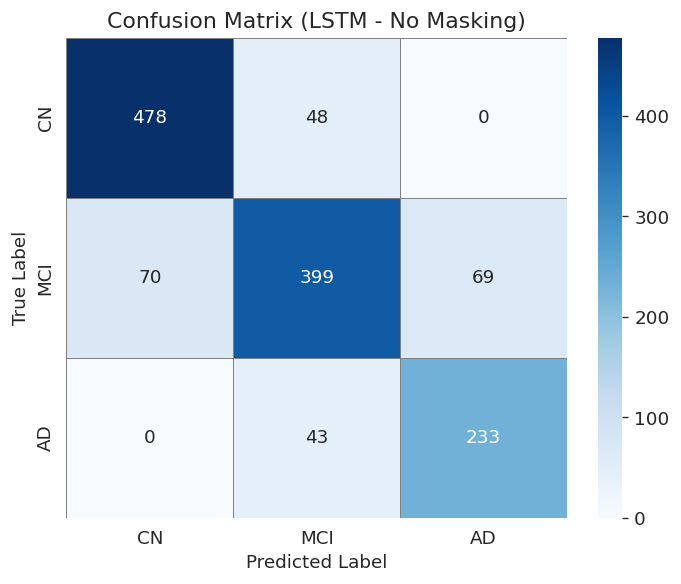

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    cbar=True,
    linewidths=0.5,
    linecolor='gray'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (LSTM - No Masking)")
plt.tight_layout()

plt.show()

In [33]:
test_meta = []

seq_id = 0

for pid, group in test_df.groupby('subject_id'):
    group = group.sort_values('visit_month').reset_index(drop=True)
    n = len(group)

    if n < 3:
        continue

    for i in range(2, n):
        start = max(0, i-3)

        input_visits = group.iloc[start:i]['visit_month'].tolist()
        target_visit = group.iloc[i]['visit_month']
        true_label = group.iloc[i][TARGET_COL]

        test_meta.append({
            "seq_id": seq_id,
            "subject_id": pid,
            "input_visits": input_visits,
            "target_visit": target_visit,
            "true": true_label
        })

        seq_id += 1

test_meta = pd.DataFrame(test_meta)

print("Meta shape:", test_meta.shape)

Meta shape: (1340, 5)


In [34]:
test_meta['pred'] = y_pred
test_meta['correct'] = (test_meta['true'] == test_meta['pred'])

In [35]:
LABEL_NAMES = ['CN', 'MCI', 'AD']

def plot_patient_trajectory(pid):
    patient_data = test_meta[test_meta['subject_id'] == pid]

    if len(patient_data) == 0:
        print("No sequences for this patient")
        return

    visits = patient_data['target_visit'].values
    true_vals = patient_data['true'].values
    pred_vals = patient_data['pred'].values

    plt.figure(figsize=(7,4))

    # True trajectory
    plt.plot(visits, true_vals, marker='o', label='True', linewidth=2)

    # Predicted trajectory
    plt.plot(visits, pred_vals, marker='x', linestyle='--', label='Predicted')

    plt.yticks([0,1,2], LABEL_NAMES)
    plt.xlabel("Visit Month")
    plt.ylabel("Diagnosis")
    plt.title(f"Patient Trajectory: {pid}")
    plt.legend()
    plt.grid(True)

    plt.show()

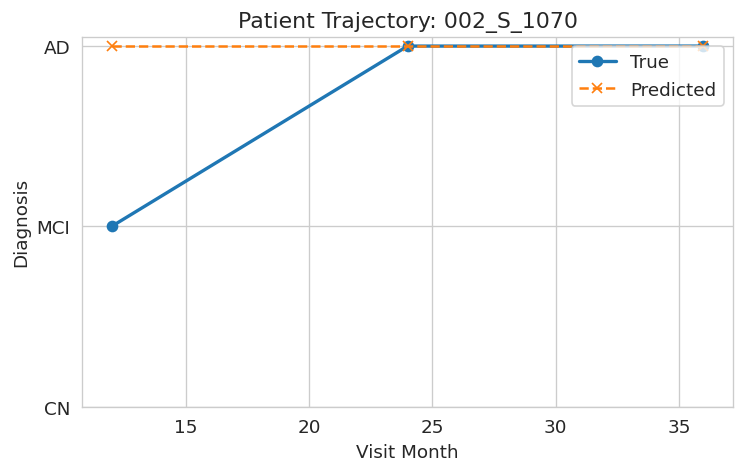

In [36]:
# pick any patient
example_pid = test_meta['subject_id'].iloc[0]

plot_patient_trajectory(example_pid)

In [37]:
# ── Number of prediction points per patient ─────────────────────────────
seq_counts = test_meta.groupby('subject_id').size()

print(seq_counts.describe())

count    397.000000
mean       3.375315
std        2.057923
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max        8.000000
dtype: float64


In [38]:
# Helper function
def get_patient_with_n_sequences(n):
    matches = seq_counts[seq_counts == n].index
    return matches[0] if len(matches) > 0 else None


📊 Patient with 1 prediction points: 002_S_6066


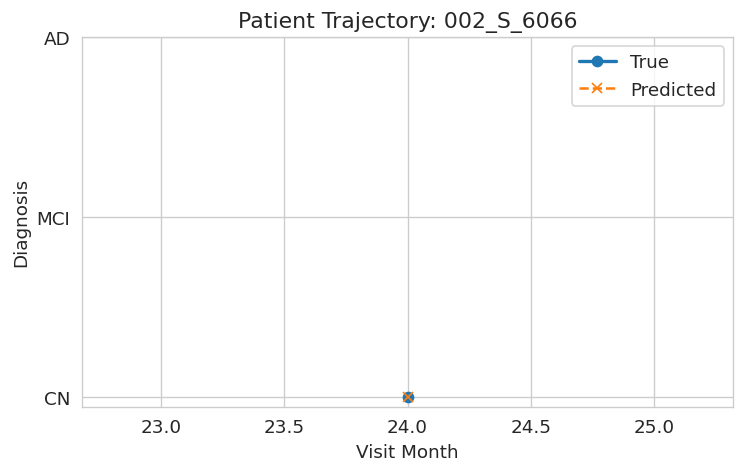


📊 Patient with 3 prediction points: 002_S_1070


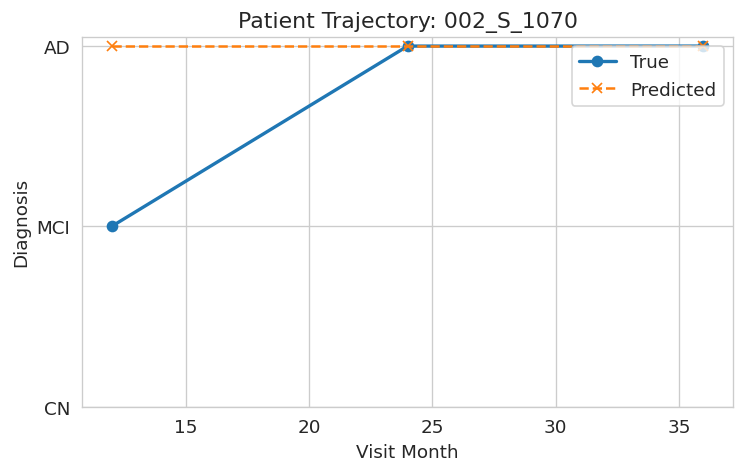


📊 Patient with 8 prediction points: 003_S_1074


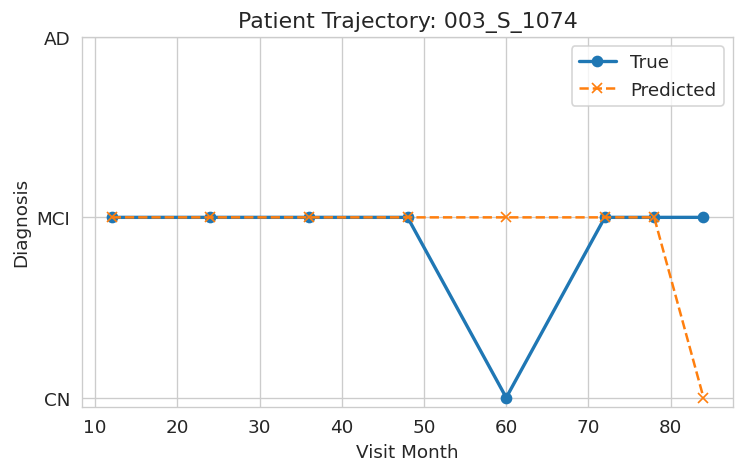

In [39]:
# Try different trajectory lengths
lengths = [1, 3, 8 ]

for n in lengths:
    pid = get_patient_with_n_sequences(n)
    
    if pid is not None:
        print(f"\n📊 Patient with {n} prediction points: {pid}")
        plot_patient_trajectory(pid)
    else:
        print(f"\n❌ No patient with exactly {n} sequences")

In [40]:
test_visit_counts = test_df.groupby('subject_id').size()

In [41]:
def get_test_patient_with_n_visits(n):
    matches = test_visit_counts[test_visit_counts == n].index
    return matches[0] if len(matches) > 0 else None


📊 Patient with 3 visits (TEST): 002_S_6066


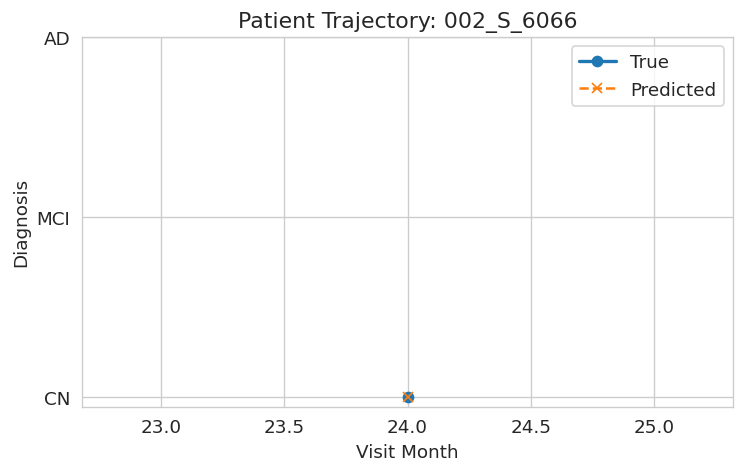


📊 Patient with 5 visits (TEST): 002_S_1070


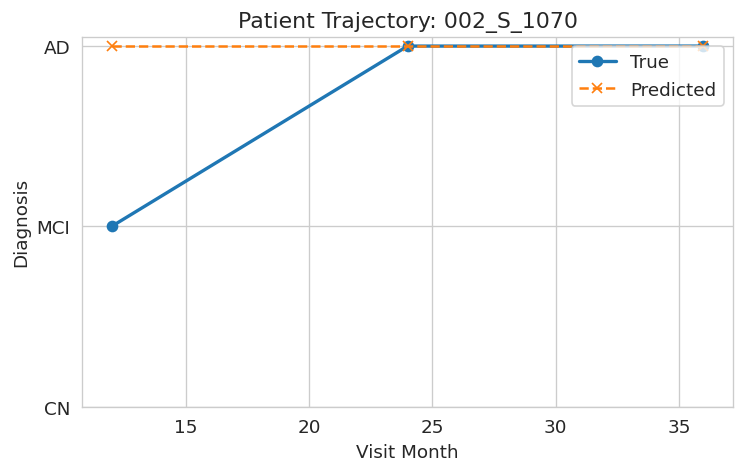


📊 Patient with 10 visits (TEST): 003_S_1074


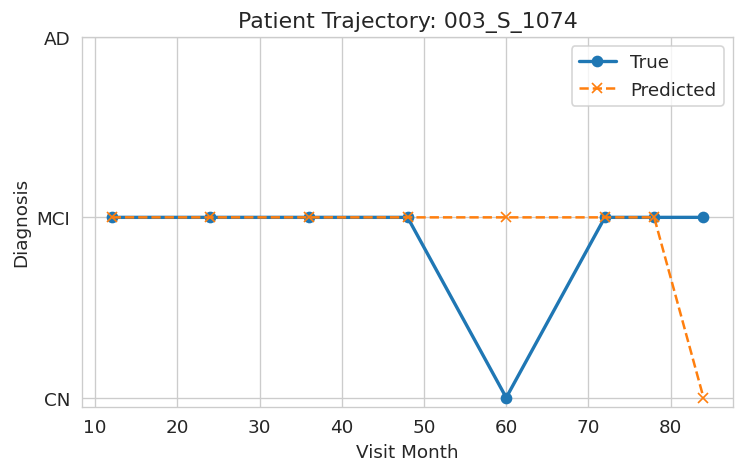

In [42]:
visit_lengths = [3, 5, 10]

for v in visit_lengths:
    pid = get_test_patient_with_n_visits(v)
    
    if pid:
        print(f"\n📊 Patient with {v} visits (TEST): {pid}")
        plot_patient_trajectory(pid)
    else:
        print(f"\n❌ No TEST patient with {v} visits")

In [43]:
from sklearn.preprocessing import label_binarize

# Convert y_test → one-hot (OvR)
y_test_bin = label_binarize(y_test, classes=[0,1,2])

print(y_test_bin.shape)  # (samples, 3)

(1340, 3)


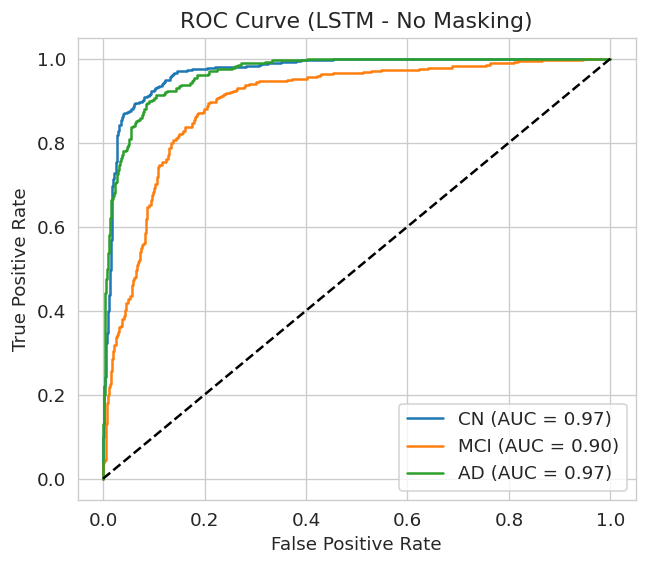

In [44]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(6,5))

for i, label in enumerate(LABEL_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

# random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LSTM - No Masking)")
plt.legend()
plt.grid(True)

plt.show()

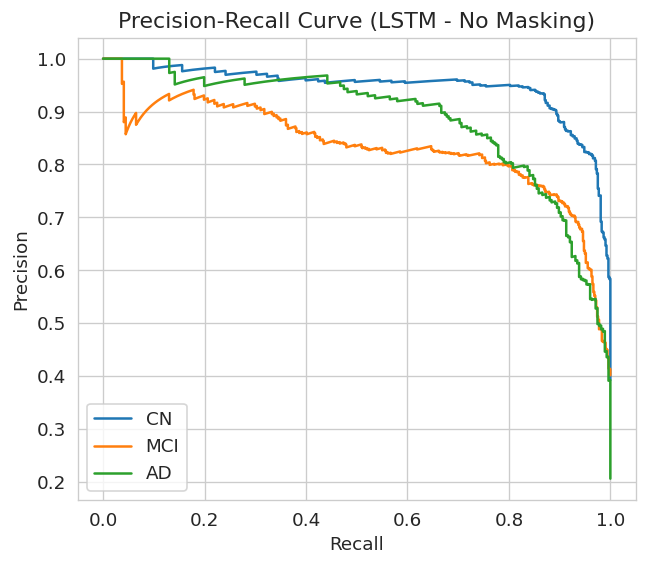

In [45]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(6,5))

for i, label in enumerate(LABEL_NAMES):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_pred_probs[:, i]
    )
    
    plt.plot(recall, precision, label=label)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LSTM - No Masking)")
plt.legend()
plt.grid(True)

plt.show()

GRU

In [46]:
from tensorflow.keras.layers import GRU

model_gru = Sequential()

model_gru.add(Bidirectional(
    GRU(
        64,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.1
    ),
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model_gru.add(BatchNormalization())

model_gru.add(Dense(32, activation='relu', kernel_regularizer=l2(1e-4)))
model_gru.add(Dropout(0.3))

model_gru.add(Dense(NUM_CLASSES, activation='softmax'))

model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        27,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,003 (125.01 KB)

 Trainable params: 31,747 (124.01 KB)

 Non-trainable params: 256 (1.00 KB)

In [47]:
model_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.5594 - loss: 0.9202 - val_accuracy: 0.5687 - val_loss: 0.9709 - learning_rate: 0.0010
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7408 - loss: 0.6346 - val_accuracy: 0.7709 - val_loss: 0.7909 - learning_rate: 0.0010
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7637 - loss: 0.5991 - val_accuracy: 0.7567 - val_loss: 0.6263 - learning_rate: 0.0010
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7650 - loss: 0.5663 - val_accuracy: 0.8157 - val_loss: 0.5132 - learning_rate: 0.0010
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7811 - loss: 0.5628 - val_accuracy: 0.7664 - val_loss: 0.5883 - learning_rate: 0.0010
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7818 - loss: 0.5490 - val_accuracy: 0.8082 - val_loss: 0.4945 - learning_rate: 0.0010
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7886 - loss: 0

In [48]:
y_pred_probs_gru = model_gru.predict(X_test)
y_pred_gru = np.argmax(y_pred_probs_gru, axis=1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


In [49]:
print(classification_report(y_test, y_pred_gru, target_names=LABEL_NAMES))

              precision    recall  f1-score   support

          CN       0.87      0.91      0.89       526
         MCI       0.80      0.77      0.78       538
          AD       0.80      0.79      0.80       276

    accuracy                           0.83      1340
   macro avg       0.82      0.82      0.82      1340
weighted avg       0.83      0.83      0.83      1340



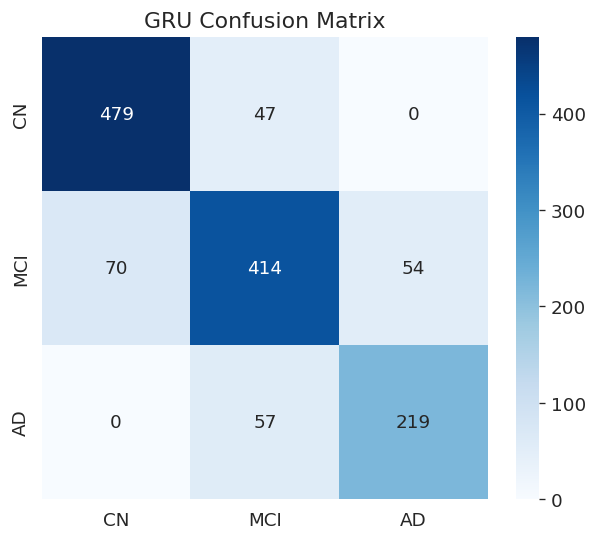

In [50]:
cm_gru = confusion_matrix(y_test, y_pred_gru)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_gru,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES
)
plt.title("GRU Confusion Matrix")
plt.show()

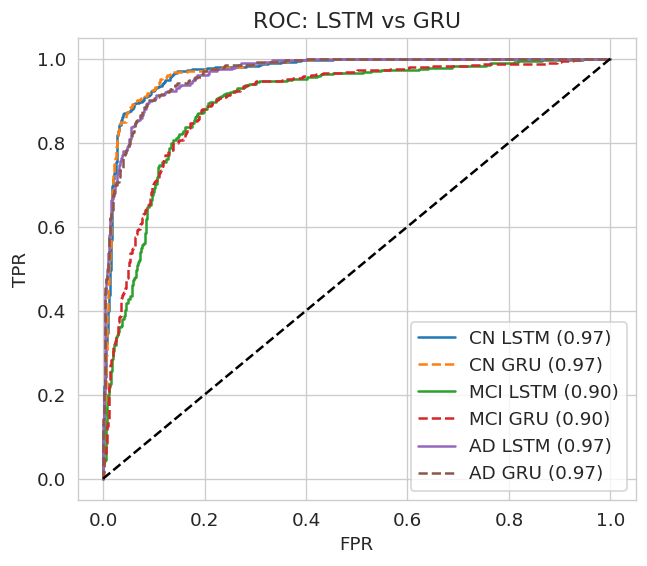

In [51]:
plt.figure(figsize=(6,5))

for i, label in enumerate(LABEL_NAMES):
    # LSTM
    fpr_l, tpr_l, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    auc_l = auc(fpr_l, tpr_l)

    # GRU
    fpr_g, tpr_g, _ = roc_curve(y_test_bin[:, i], y_pred_probs_gru[:, i])
    auc_g = auc(fpr_g, tpr_g)

    plt.plot(fpr_l, tpr_l, linestyle='-', label=f"{label} LSTM ({auc_l:.2f})")
    plt.plot(fpr_g, tpr_g, linestyle='--', label=f"{label} GRU ({auc_g:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC: LSTM vs GRU")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()

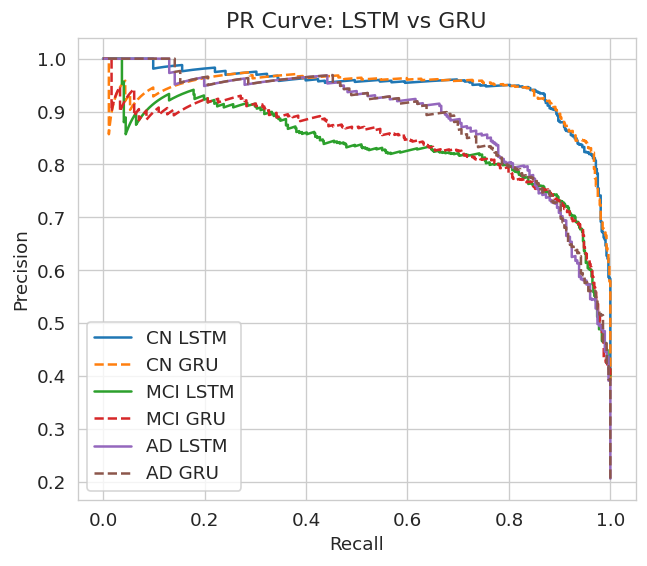

In [52]:
plt.figure(figsize=(6,5))

for i, label in enumerate(LABEL_NAMES):
    # LSTM
    p_l, r_l, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs[:, i])
    
    # GRU
    p_g, r_g, _ = precision_recall_curve(y_test_bin[:, i], y_pred_probs_gru[:, i])

    plt.plot(r_l, p_l, linestyle='-', label=f"{label} LSTM")
    plt.plot(r_g, p_g, linestyle='--', label=f"{label} GRU")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve: LSTM vs GRU")
plt.legend()
plt.grid(True)
plt.show()

While LSTM and GRU achieve similar ROC performance, their behavior differs significantly in clinically relevant regimes.

LSTM is better at modeling transitional disease states (MCI),
while GRU favors stable progression patterns and achieves higher recall in advanced disease (AD).

Model choice should depend on trajectory characteristics:

• Use GRU → smooth, stable progression  
• Use LSTM → noisy, variable progression (real-world clinical data)

Masking

In [53]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MASK_VALUE = -999
MAX_LEN = 3

X_train_mask = pad_sequences(
    X_train_raw,
    maxlen=MAX_LEN,
    dtype='float32',
    padding='pre',
    value=MASK_VALUE
)

X_test_mask = pad_sequences(
    X_test_raw,
    maxlen=MAX_LEN,
    dtype='float32',
    padding='pre',
    value=MASK_VALUE
)

print("Shapes:")
print("X_train_mask:", X_train_mask.shape)
print("X_test_mask :", X_test_mask.shape)

# Check mask presence
print("\nMask count (train):", np.sum(X_train_mask == MASK_VALUE))
print("Mask count (test) :", np.sum(X_test_mask == MASK_VALUE))

# Inspect one sample
print("\nSample sequence:")
print(X_train_mask[0])

Shapes:
X_train_mask: (5560, 3, 5)
X_test_mask : (1340, 3, 5)

Mask count (train): 7820
Mask count (test) : 1985

Sample sequence:
[[-999.   -999.   -999.   -999.   -999.  ]
 [  84.84    0.     28.      3.      0.  ]
 [  84.84    0.     28.      5.33    6.  ]]


In [54]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_2d = X_train_mask.reshape(-1, X_train_mask.shape[-1])
X_test_2d  = X_test_mask.reshape(-1, X_test_mask.shape[-1])

# Identify valid rows (not fully masked)
train_valid = ~(X_train_2d == MASK_VALUE).all(axis=1)
test_valid  = ~(X_test_2d == MASK_VALUE).all(axis=1)

# 🔥 NEW: Replace NaNs ONLY in valid rows
X_train_2d[train_valid] = np.nan_to_num(X_train_2d[train_valid], nan=0.0)
X_test_2d[test_valid]   = np.nan_to_num(X_test_2d[test_valid], nan=0.0)

# Fit on valid rows
scaler.fit(X_train_2d[train_valid])

# Transform valid rows
X_train_2d[train_valid] = scaler.transform(X_train_2d[train_valid])
X_test_2d[test_valid]   = scaler.transform(X_test_2d[test_valid])

# Restore mask rows
X_train_2d[~train_valid] = MASK_VALUE
X_test_2d[~test_valid]   = MASK_VALUE

# reshape back
X_train_mask = X_train_2d.reshape(X_train_mask.shape)
X_test_mask  = X_test_2d.reshape(X_test_mask.shape)

# ── CHECKS ─────────────────────────────────────────────
print("Min value:", np.nanmin(X_train_mask))
print("Max value:", np.nanmax(X_train_mask))

print("NaNs remaining:", np.isnan(X_train_mask).sum())
print("Mask still present:", np.sum(X_train_mask == MASK_VALUE))

print("\nSample sequence:")
print(X_train_mask[0])

Min value: -999.0
Max value: 1.0
NaNs remaining: 0
Mask still present: 7820

Sample sequence:
[[-9.9900000e+02 -9.9900000e+02 -9.9900000e+02 -9.9900000e+02
  -9.9900000e+02]
 [ 8.1930017e-01  0.0000000e+00  9.3333340e-01  4.2857144e-02
   0.0000000e+00]
 [ 8.1930017e-01  0.0000000e+00  9.3333340e-01  7.6142855e-02
   7.6923080e-02]]


In [55]:
from tensorflow.keras.layers import Masking

model_mask = Sequential()

# 🔥 Masking layer MUST be first
model_mask.add(Masking(
    mask_value=MASK_VALUE,
    input_shape=(X_train_mask.shape[1], X_train_mask.shape[2])
))

model_mask.add(Bidirectional(
    LSTM(
        64,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.1
    )
))

model_mask.add(BatchNormalization())

model_mask.add(Dense(32, activation='relu', kernel_regularizer=l2(1e-4)))
model_mask.add(Dropout(0.3))

model_mask.add(Dense(NUM_CLASSES, activation='softmax'))

model_mask.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 3, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,579 (158.51 KB)

 Trainable params: 40,323 (157.51 KB)

 Non-trainable params: 256 (1.00 KB)

In [56]:
print(X_train_mask.shape)
print(np.unique(y_train))

(5560, 3, 5)
[0 1 2]


In [57]:
model_mask.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

history_mask = model_mask.fit(
    X_train_mask, y_train,
    validation_data=(X_test_mask, y_test),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.5718 - loss: 0.8882 - val_accuracy: 0.7045 - val_loss: 0.9654 - learning_rate: 0.0010
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7557 - loss: 0.6243 - val_accuracy: 0.7649 - val_loss: 0.8434 - learning_rate: 0.0010
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7517 - loss: 0.6064 - val_accuracy: 0.7269 - val_loss: 0.6692 - learning_rate: 0.0010
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7650 - loss: 0.5778 - val_accuracy: 0.6903 - val_loss: 0.6079 - learning_rate: 0.0010
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7880 - loss: 0.5509 - val_accuracy: 0.7440 - val_loss: 0.5472 - learning_rate: 0.0010
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7980 - loss: 0.5314 - val_accuracy: 0.6478 - val_loss: 0.6740 - learning_rate: 0.0010
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7945 - loss: 0

In [58]:
y_pred_probs_mask = model_mask.predict(X_test_mask)
y_pred_mask = np.argmax(y_pred_probs_mask, axis=1)

print("Masked LSTM Report:\n")
print(classification_report(y_test, y_pred_mask, target_names=LABEL_NAMES))

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
Masked LSTM Report:

              precision    recall  f1-score   support

          CN       0.89      0.90      0.89       526
         MCI       0.83      0.69      0.75       538
          AD       0.69      0.90      0.78       276

    accuracy                           0.81      1340
   macro avg       0.80      0.83      0.81      1340
weighted avg       0.82      0.81      0.81      1340



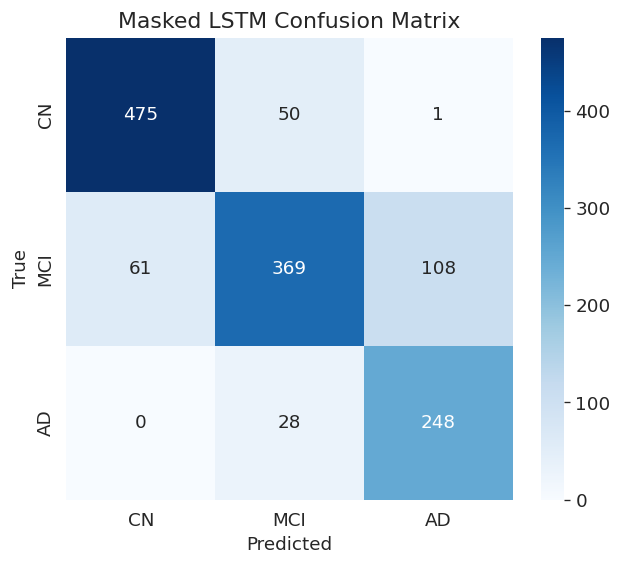

In [59]:
cm_mask = confusion_matrix(y_test, y_pred_mask)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_mask,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES
)

plt.title("Masked LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [60]:
# Add predictions
test_meta['pred_nomask'] = y_pred
test_meta['pred_mask'] = y_pred_mask

In [61]:
LABEL_NAMES = ['CN', 'MCI', 'AD']

def plot_patient_comparison(pid):
    data = test_meta[test_meta['subject_id'] == pid]

    if len(data) == 0:
        print("No sequences for this patient")
        return

    visits = data['target_visit'].values
    true_vals = data['true'].values
    pred_nomask = data['pred_nomask'].values
    pred_mask = data['pred_mask'].values

    plt.figure(figsize=(7,4))

    # True
    plt.plot(visits, true_vals, marker='o', linewidth=2, label='True')

    # No Mask
    plt.plot(visits, pred_nomask, marker='x', linestyle='--', label='No Mask')

    # Masked
    plt.plot(visits, pred_mask, marker='s', linestyle='-.', label='Masked')

    plt.yticks([0,1,2], LABEL_NAMES)
    plt.xlabel("Visit Month")
    plt.ylabel("Diagnosis")
    plt.title(f"Trajectory Comparison: {pid}")
    plt.legend()
    plt.grid(True)

    plt.show()

In [62]:
# Find sequences where predictions differ
diff_pids = test_meta[
    test_meta['pred_nomask'] != test_meta['pred_mask']
]['subject_id'].unique()

print("Patients with disagreement:", len(diff_pids))

Patients with disagreement: 58



📊 Patient: 002_S_4654


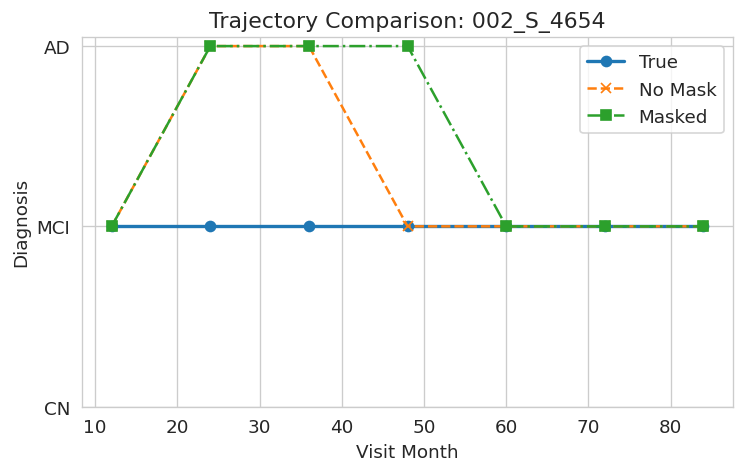


📊 Patient: 003_S_1074


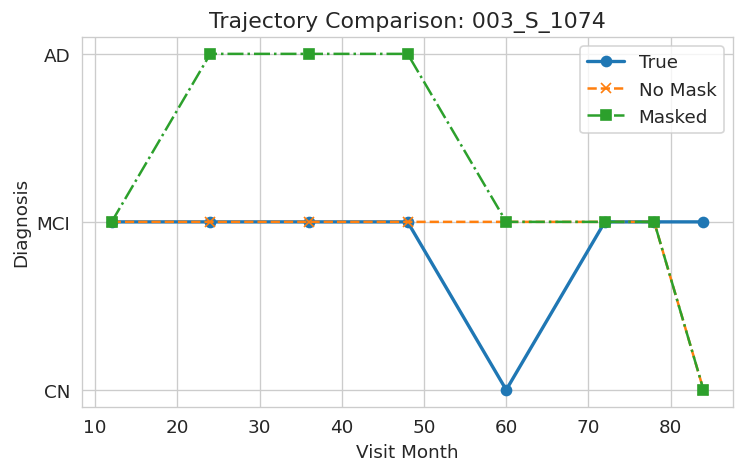


📊 Patient: 003_S_4354


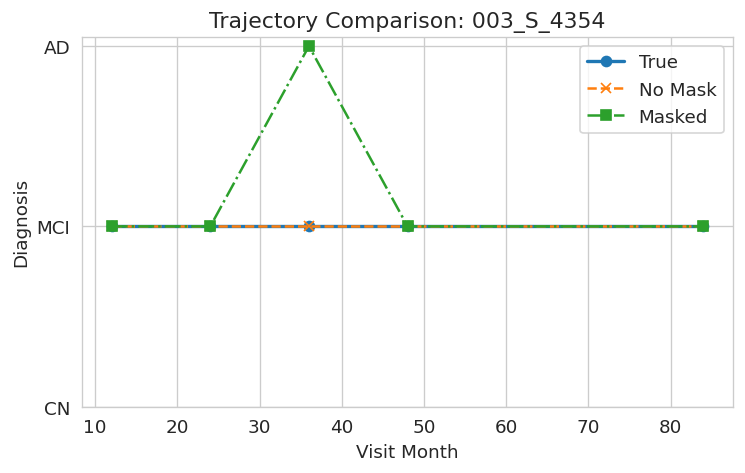


📊 Patient: 005_S_1224


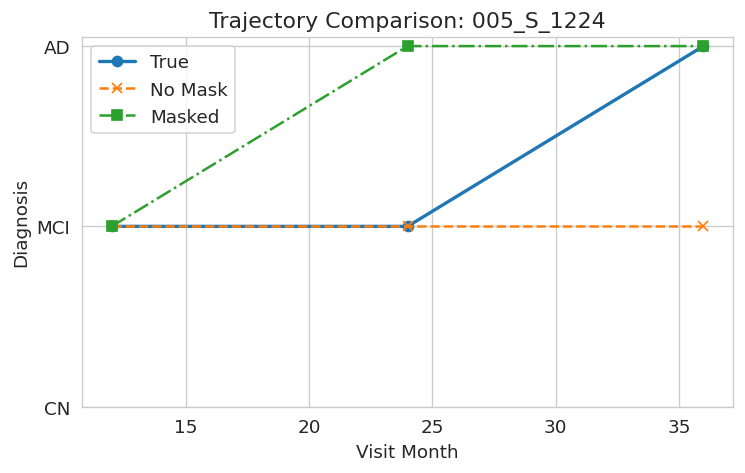


📊 Patient: 007_S_0293


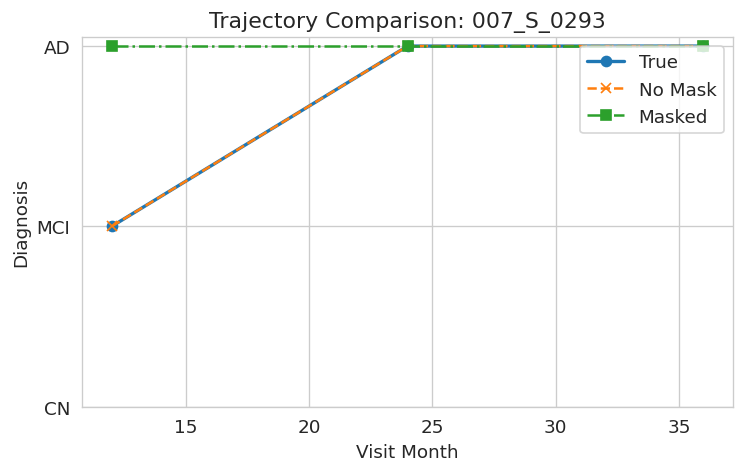

In [63]:
for pid in diff_pids[:5]:
    print(f"\n📊 Patient: {pid}")
    plot_patient_comparison(pid)

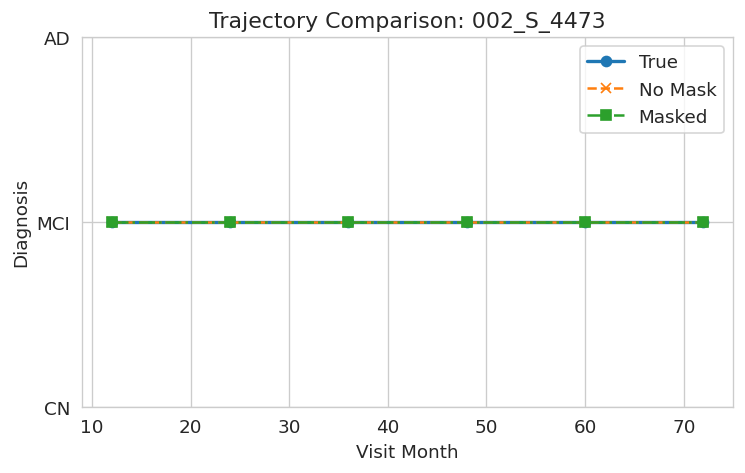

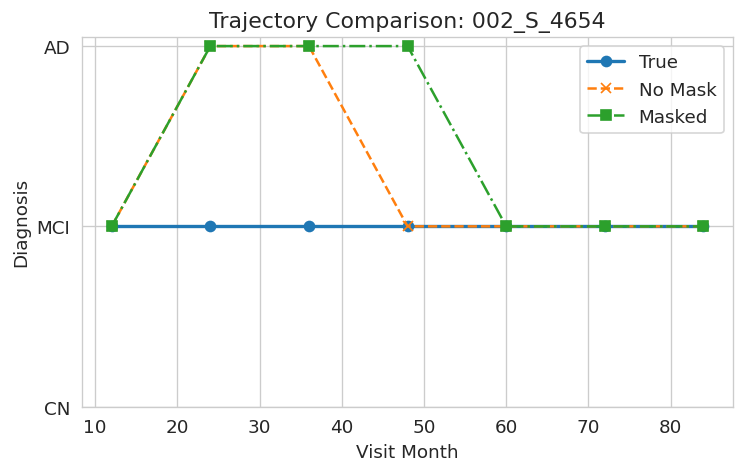

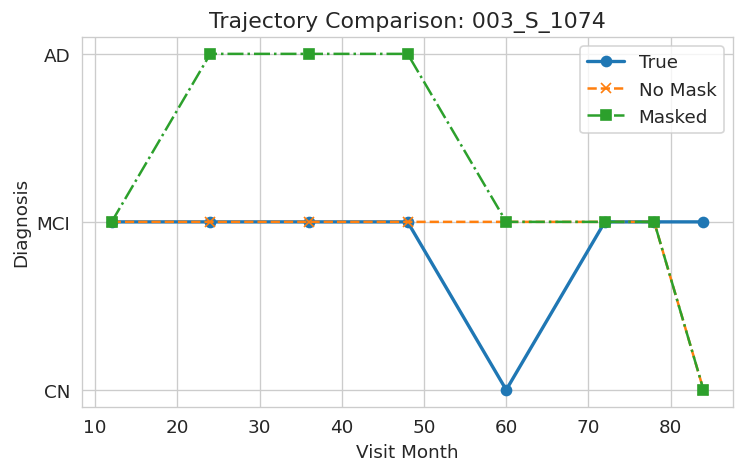

In [64]:
seq_counts = test_meta.groupby('subject_id').size()

long_pids = seq_counts[seq_counts >= 5].index

for pid in long_pids[:3]:
    plot_patient_comparison(pid)

In [65]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

In [66]:
from sklearn.metrics import roc_curve, auc

print("Masked LSTM ROC AUC:\n")

auc_scores_mask = {}

for i, label in enumerate(LABEL_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs_mask[:, i])
    roc_auc = auc(fpr, tpr)
    
    auc_scores_mask[label] = roc_auc
    print(f"{label}: {roc_auc:.4f}")

Masked LSTM ROC AUC:

CN: 0.9718
MCI: 0.9032
AD: 0.9662


In [67]:
# Micro-average
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_pred_probs_mask.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

# Macro-average
all_auc = list(auc_scores_mask.values())
auc_macro = sum(all_auc) / len(all_auc)

print("\nMicro AUC:", round(auc_micro, 4))
print("Macro AUC:", round(auc_macro, 4))


Micro AUC: 0.9441
Macro AUC: 0.9471


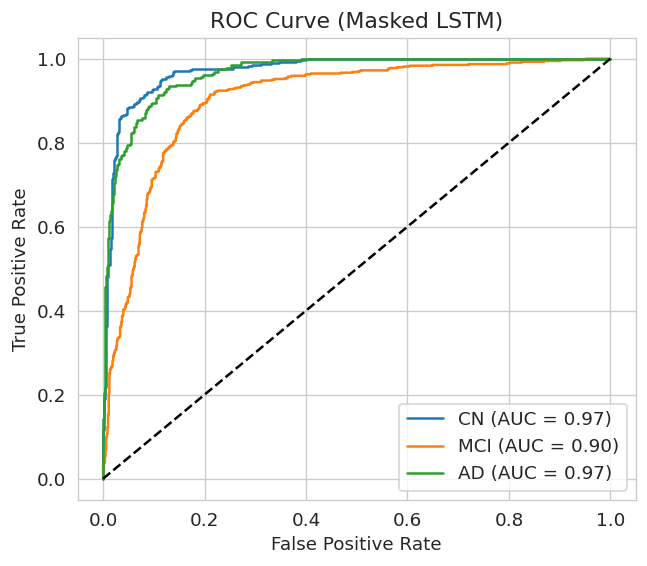

In [68]:
plt.figure(figsize=(6,5))

for i, label in enumerate(LABEL_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs_mask[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Masked LSTM)")
plt.legend()
plt.grid(True)

plt.show()

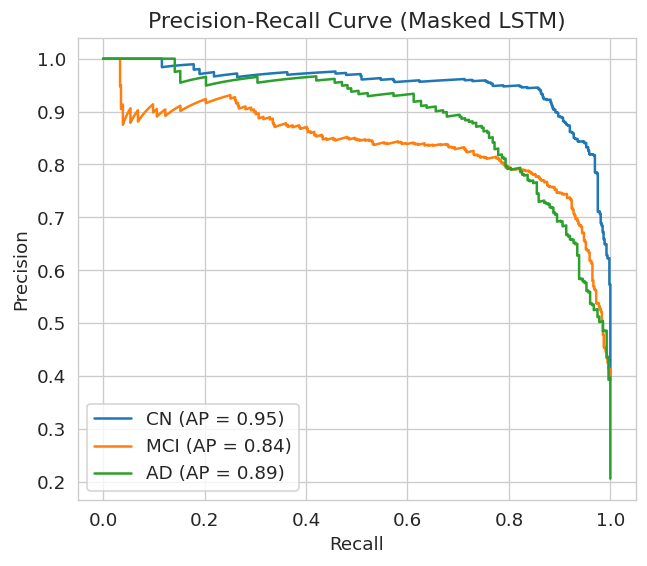

In [69]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(6,5))

ap_scores = {}

for i, label in enumerate(LABEL_NAMES):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_pred_probs_mask[:, i]
    )
    
    ap = average_precision_score(
        y_test_bin[:, i],
        y_pred_probs_mask[:, i]
    )
    
    ap_scores[label] = ap
    
    plt.plot(recall, precision, label=f"{label} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Masked LSTM)")
plt.legend()
plt.grid(True)

plt.show()

masked gru

In [70]:
from tensorflow.keras.layers import GRU, Masking

model_gru_mask = Sequential()

# Masking FIRST
model_gru_mask.add(Masking(
    mask_value=MASK_VALUE,
    input_shape=(X_train_mask.shape[1], X_train_mask.shape[2])
))

model_gru_mask.add(Bidirectional(
    GRU(
        64,
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.1
    )
))

model_gru_mask.add(BatchNormalization())

model_gru_mask.add(Dense(32, activation='relu', kernel_regularizer=l2(1e-4)))
model_gru_mask.add(Dropout(0.3))

model_gru_mask.add(Dense(NUM_CLASSES, activation='softmax'))

model_gru_mask.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 3, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        27,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,003 (125.01 KB)

 Trainable params: 31,747 (124.01 KB)

 Non-trainable params: 256 (1.00 KB)

In [71]:
print(X_train_mask.shape)
print(np.unique(y_train))

(5560, 3, 5)
[0 1 2]


In [72]:
model_gru_mask.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_gru_mask = model_gru_mask.fit(
    X_train_mask, y_train,
    validation_data=(X_test_mask, y_test),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.5775 - loss: 0.9045 - val_accuracy: 0.5791 - val_loss: 0.9670 - learning_rate: 0.0010
Epoch 2/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7366 - loss: 0.6429 - val_accuracy: 0.5828 - val_loss: 0.8546 - learning_rate: 0.0010
Epoch 3/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7445 - loss: 0.6061 - val_accuracy: 0.5851 - val_loss: 0.7075 - learning_rate: 0.0010
Epoch 4/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7681 - loss: 0.5749 - val_accuracy: 0.6455 - val_loss: 0.6729 - learning_rate: 0.0010
Epoch 5/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7706 - loss: 0.5632 - val_accuracy: 0.7000 - val_loss: 0.5838 - learning_rate: 0.0010
Epoch 6/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7852 - loss: 0.5472 - val_accuracy: 0.7709 - val_loss: 0.5193 - learning_rate: 0.0010
Epoch 7/30
174/174 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7903 - loss: 0

In [73]:
y_pred_probs_gru_mask = model_gru_mask.predict(X_test_mask)
y_pred_gru_mask = np.argmax(y_pred_probs_gru_mask, axis=1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


In [74]:
print("Masked GRU Report:\n")
print(classification_report(y_test, y_pred_gru_mask, target_names=LABEL_NAMES))

Masked GRU Report:

              precision    recall  f1-score   support

          CN       0.88      0.91      0.90       526
         MCI       0.83      0.66      0.74       538
          AD       0.68      0.90      0.78       276

    accuracy                           0.81      1340
   macro avg       0.80      0.83      0.80      1340
weighted avg       0.82      0.81      0.81      1340



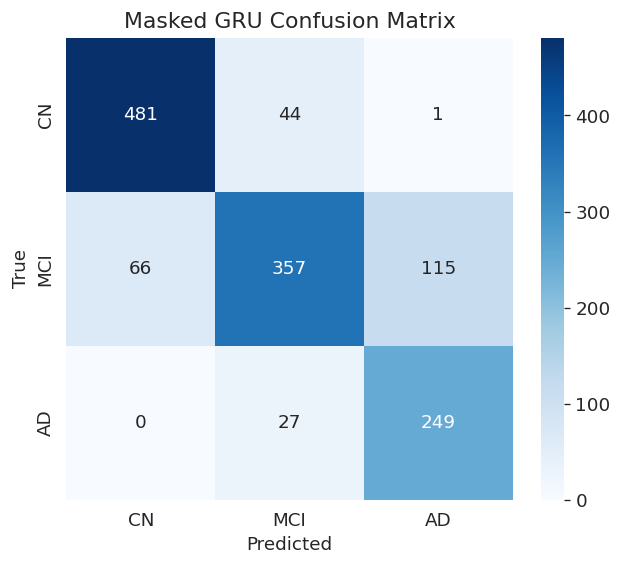

In [75]:
cm_gru_mask = confusion_matrix(y_test, y_pred_gru_mask)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_gru_mask,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES
)

plt.title("Masked GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

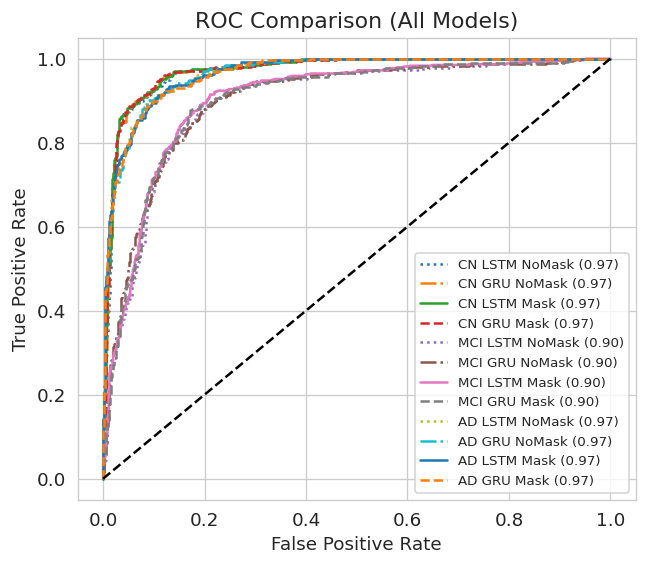

In [76]:
plt.figure(figsize=(6,5))

for i, label in enumerate(LABEL_NAMES):
    # ── LSTM No Mask ─────────────────────────
    fpr_nm, tpr_nm, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    auc_nm = auc(fpr_nm, tpr_nm)

    # ── GRU No Mask ──────────────────────────
    fpr_gnm, tpr_gnm, _ = roc_curve(y_test_bin[:, i], y_pred_probs_gru[:, i])
    auc_gnm = auc(fpr_gnm, tpr_gnm)

    # ── LSTM Mask ────────────────────────────
    fpr_lm, tpr_lm, _ = roc_curve(y_test_bin[:, i], y_pred_probs_mask[:, i])
    auc_lm = auc(fpr_lm, tpr_lm)

    # ── GRU Mask ─────────────────────────────
    fpr_gm, tpr_gm, _ = roc_curve(y_test_bin[:, i], y_pred_probs_gru_mask[:, i])
    auc_gm = auc(fpr_gm, tpr_gm)

    # Plot
    plt.plot(fpr_nm, tpr_nm, linestyle=':',  label=f"{label} LSTM NoMask ({auc_nm:.2f})")
    plt.plot(fpr_gnm, tpr_gnm, linestyle='-.', label=f"{label} GRU NoMask ({auc_gnm:.2f})")
    plt.plot(fpr_lm, tpr_lm, linestyle='-',  label=f"{label} LSTM Mask ({auc_lm:.2f})")
    plt.plot(fpr_gm, tpr_gm, linestyle='--', label=f"{label} GRU Mask ({auc_gm:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Comparison (All Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
plt.grid(True)

plt.show()

patients

In [77]:
test_meta['lstm_nomask'] = y_pred
test_meta['gru_nomask'] = y_pred_gru
test_meta['lstm_mask'] = y_pred_mask
test_meta['gru_mask'] = y_pred_gru_mask

In [78]:
LABEL_NAMES = ['CN', 'MCI', 'AD']

def plot_patient_all_models(pid):
    data = test_meta[test_meta['subject_id'] == pid]

    if len(data) == 0:
        print("No sequences for this patient")
        return

    visits = data['target_visit'].values
    true_vals = data['true'].values

    plt.figure(figsize=(8,4))

    # True
    plt.plot(visits, true_vals, marker='o', linewidth=3, label='True', color='black')

    # LSTM No Mask
    plt.plot(visits, data['lstm_nomask'], linestyle=':', marker='x', label='LSTM NoMask')

    # GRU No Mask
    plt.plot(visits, data['gru_nomask'], linestyle='-.', marker='x', label='GRU NoMask')

    # LSTM Mask
    plt.plot(visits, data['lstm_mask'], linestyle='-', marker='s', label='LSTM Mask')

    # GRU Mask
    plt.plot(visits, data['gru_mask'], linestyle='--', marker='d', label='GRU Mask')

    plt.yticks([0,1,2], LABEL_NAMES)
    plt.xlabel("Visit Month")
    plt.ylabel("Diagnosis")
    plt.title(f"Patient Trajectory Comparison: {pid}")
    plt.legend()
    plt.grid(True)

    plt.show()

In [79]:
seq_counts = test_meta.groupby('subject_id').size()

# variability (std dev of true labels)
variability = test_meta.groupby('subject_id')['true'].std()

patient_stats = pd.DataFrame({
    'seq_len': seq_counts,
    'std': variability
}).fillna(0)

In [80]:
selected_pids = []

# 1. Short sequence (low history)
selected_pids.append(patient_stats[patient_stats['seq_len'] == 1].index[0])

# 2. Medium length
selected_pids.append(patient_stats[patient_stats['seq_len'].between(3,5)].index[0])

# 3. Long sequence
selected_pids.append(patient_stats[patient_stats['seq_len'] >= 7].index[0])

# 4. High variability (noisy)
selected_pids.append(patient_stats.sort_values('std', ascending=False).index[0])

# 5. Stable patient (low variability)
selected_pids.append(patient_stats.sort_values('std', ascending=True).index[0])

print("Selected patients:", selected_pids)

Selected patients: ['002_S_6066', '002_S_1070', '002_S_4654', '029_S_4385', '094_S_2238']



📊 Patient: 002_S_6066


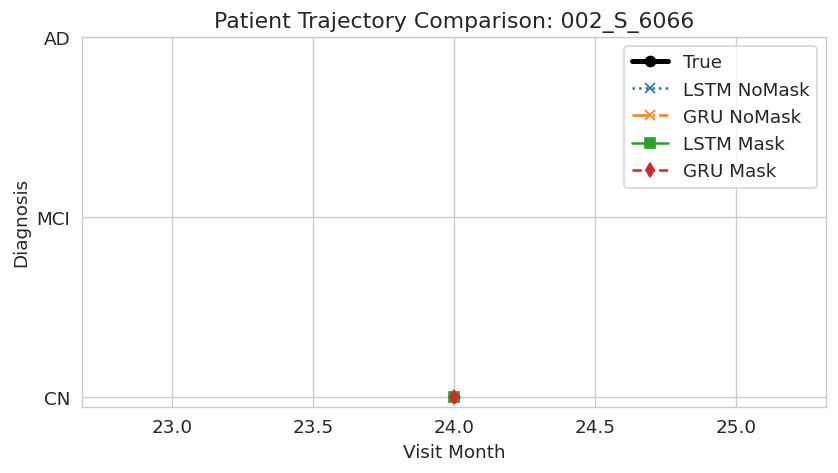


📊 Patient: 002_S_1070


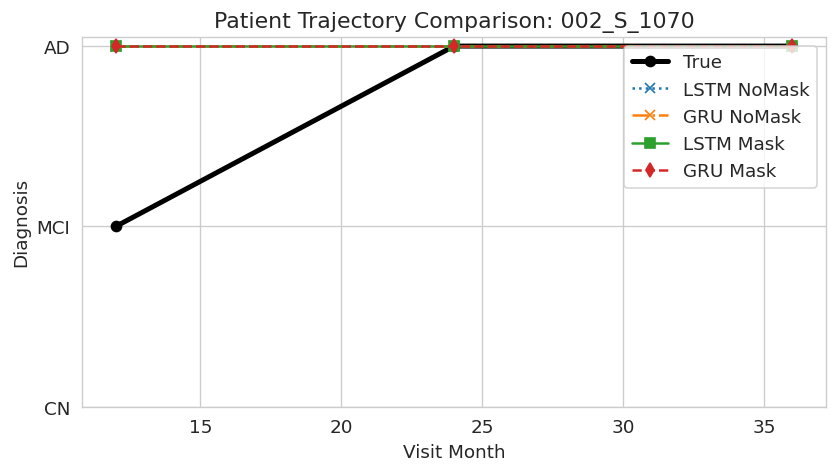


📊 Patient: 002_S_4654


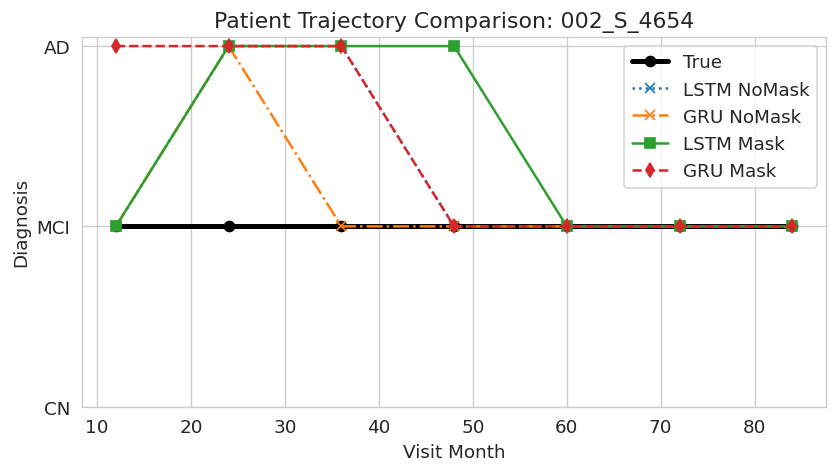


📊 Patient: 029_S_4385


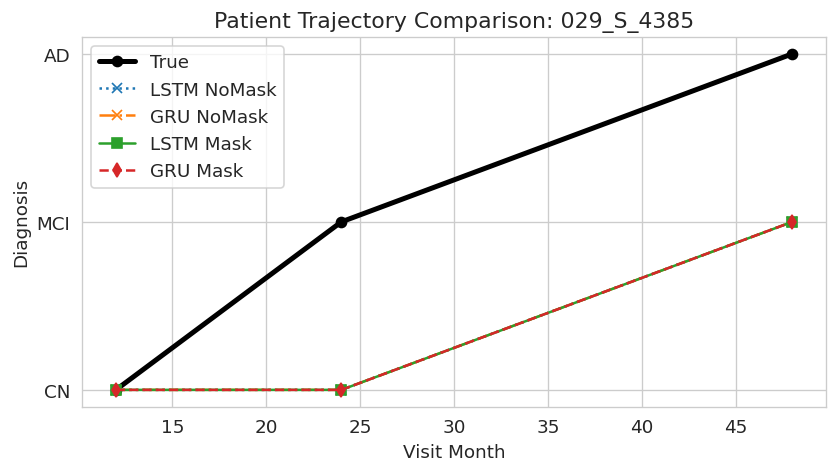


📊 Patient: 094_S_2238


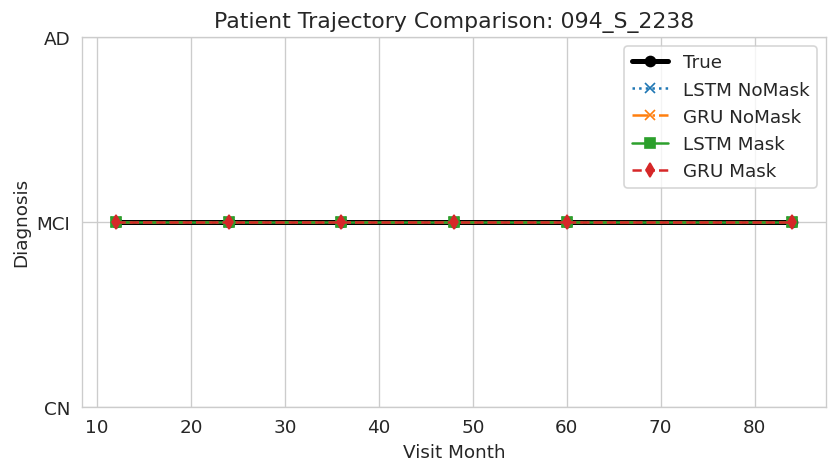

In [81]:
for pid in selected_pids:
    print(f"\n📊 Patient: {pid}")
    plot_patient_all_models(pid)

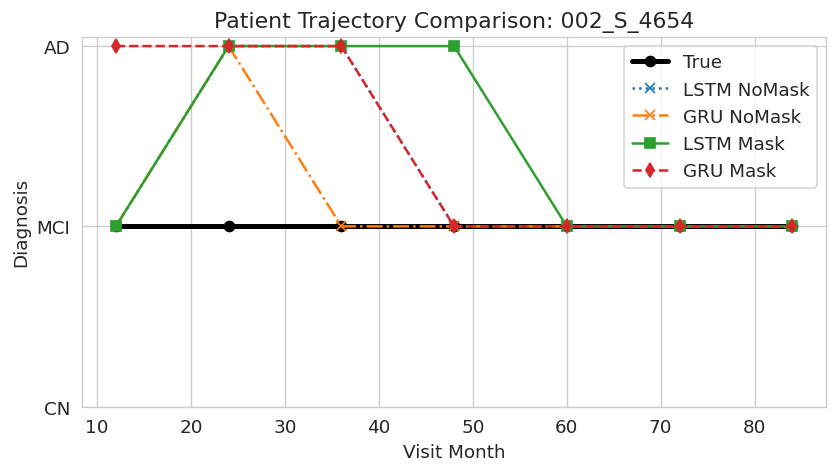

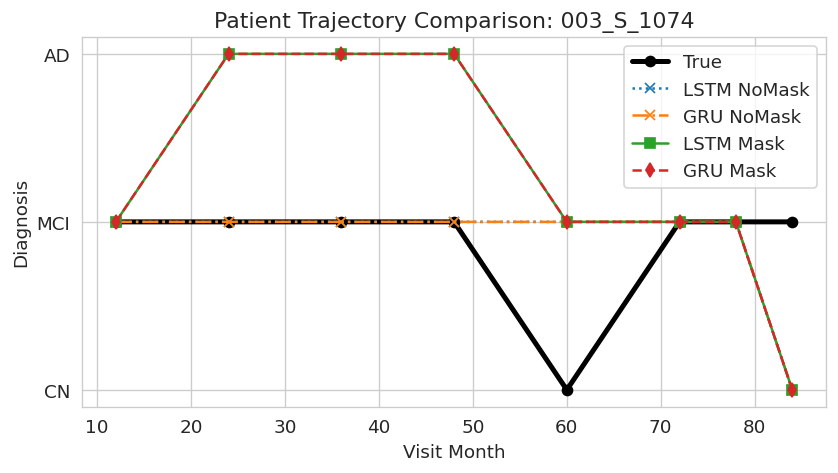

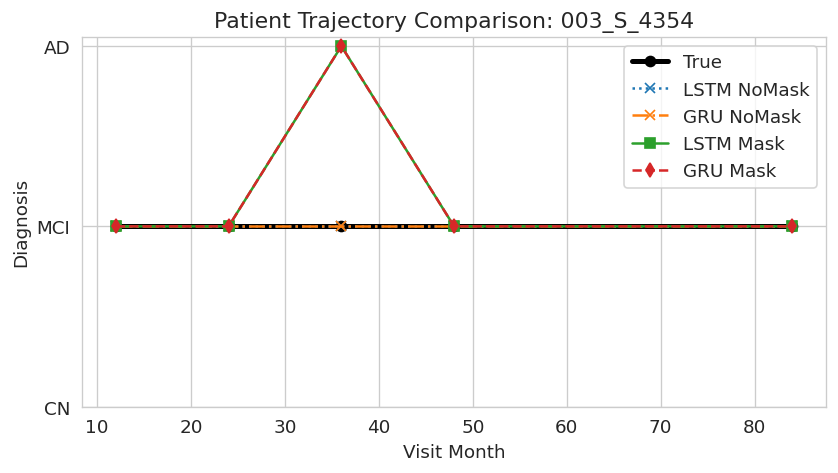

In [82]:
diff = test_meta[
    (test_meta['lstm_nomask'] != test_meta['lstm_mask']) |
    (test_meta['gru_nomask'] != test_meta['gru_mask'])
]

interesting_pids = diff['subject_id'].unique()[:3]

for pid in interesting_pids:
    plot_patient_all_models(pid)

final output

In [83]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0,1,2], zero_division=0
    )
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        
        'Precision_CN': precision[0],
        'Precision_MCI': precision[1],
        'Precision_AD': precision[2],
        
        'Recall_CN': recall[0],
        'Recall_MCI': recall[1],
        'Recall_AD': recall[2],
        
        'F1_CN': f1[0],
        'F1_MCI': f1[1],
        'F1_AD': f1[2],
    }

results = []

# LSTM No Mask
results.append(get_metrics(y_test, y_pred, "LSTM_NoMask"))

# GRU No Mask
results.append(get_metrics(y_test, y_pred_gru, "GRU_NoMask"))

# LSTM Mask
results.append(get_metrics(y_test, y_pred_mask, "LSTM_Mask"))

# GRU Mask
results.append(get_metrics(y_test, y_pred_gru_mask, "GRU_Mask"))

df_results = pd.DataFrame(results)
df_results = df_results.round(3)

df_results

,Model,Accuracy,Precision_CN,Precision_MCI,Precision_AD,Recall_CN,Recall_MCI,Recall_AD,F1_CN,F1_MCI,F1_AD
0,LSTM_NoMask,0.828,0.872,0.814,0.772,0.909,0.742,0.844,0.890,0.776,0.806
1,GRU_NoMask,0.830,0.872,0.799,0.802,0.911,0.770,0.793,0.891,0.784,0.798
2,LSTM_Mask,0.815,0.886,0.826,0.695,0.903,0.686,0.899,0.895,0.749,0.784
3,GRU_Mask,0.811,0.879,0.834,0.682,0.914,0.664,0.902,0.897,0.739,0.777


In [84]:
cols = [
    'Model', 'Accuracy',
    'Precision_CN', 'Recall_CN',
    'Precision_MCI', 'Recall_MCI',
    'Precision_AD', 'Recall_AD'
]

df_results[cols]

,Model,Accuracy,Precision_CN,Recall_CN,Precision_MCI,Recall_MCI,Precision_AD,Recall_AD
0,LSTM_NoMask,0.828,0.872,0.909,0.814,0.742,0.772,0.844
1,GRU_NoMask,0.830,0.872,0.911,0.799,0.770,0.802,0.793
2,LSTM_Mask,0.815,0.886,0.903,0.826,0.686,0.695,0.899
3,GRU_Mask,0.811,0.879,0.914,0.834,0.664,0.682,0.902


1. Performance vs Sequence Length

In [85]:
# Add sequence length
test_meta['seq_len'] = test_meta['input_visits'].apply(len)

# sanity check
print(test_meta[['input_visits', 'seq_len']].head())

  input_visits  seq_len
0       [0, 6]        2
1   [0, 6, 12]        3
2  [6, 12, 24]        3
3       [0, 6]        2
4   [0, 6, 12]        3


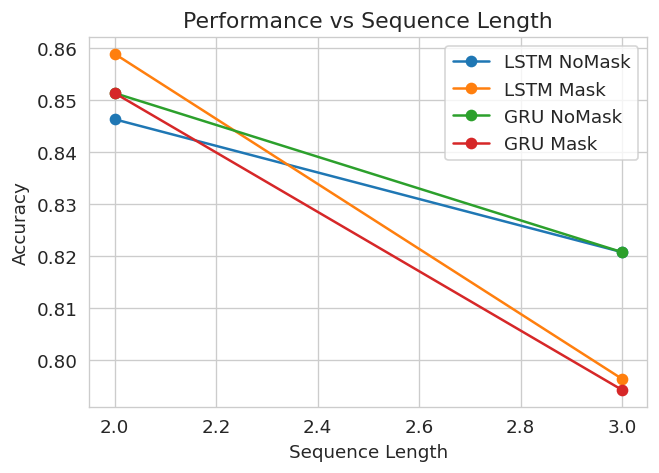

In [86]:
def eval_by_seq_length(meta, y_true, y_pred, name):
    df = meta.copy()
    df['pred'] = y_pred

    df['correct'] = (df['true'] == df['pred']).astype(int)

    grouped = df.groupby('seq_len')['correct'].mean()

    plt.plot(grouped.index, grouped.values, marker='o', label=name)

plt.figure(figsize=(6,4))

eval_by_seq_length(test_meta, y_test, y_pred, "LSTM NoMask")
eval_by_seq_length(test_meta, y_test, y_pred_mask, "LSTM Mask")
eval_by_seq_length(test_meta, y_test, y_pred_gru, "GRU NoMask")
eval_by_seq_length(test_meta, y_test, y_pred_gru_mask, "GRU Mask")

plt.xlabel("Sequence Length")
plt.ylabel("Accuracy")
plt.title("Performance vs Sequence Length")
plt.legend()
plt.grid(True)
plt.show()

Error Analysis by Class

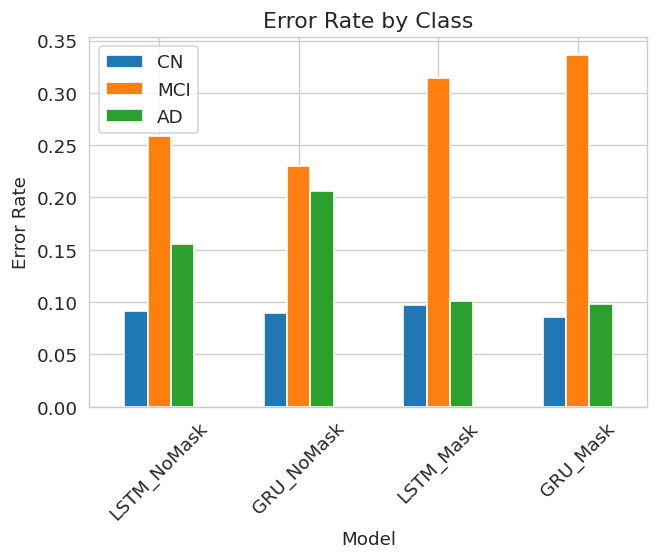

In [87]:
def class_error(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    errors = cm.sum(axis=1) - np.diag(cm)
    return errors / cm.sum(axis=1)

models = {
    "LSTM_NoMask": y_pred,
    "GRU_NoMask": y_pred_gru,
    "LSTM_Mask": y_pred_mask,
    "GRU_Mask": y_pred_gru_mask
}

error_df = []

for name, preds in models.items():
    err = class_error(y_test, preds)
    error_df.append([name] + list(err))

error_df = pd.DataFrame(error_df, columns=['Model','CN','MCI','AD'])

error_df.set_index('Model').plot(kind='bar', figsize=(6,4))
plt.title("Error Rate by Class")
plt.ylabel("Error Rate")
plt.xticks(rotation=45)
plt.show()

3. Prediction Confidence Distribution

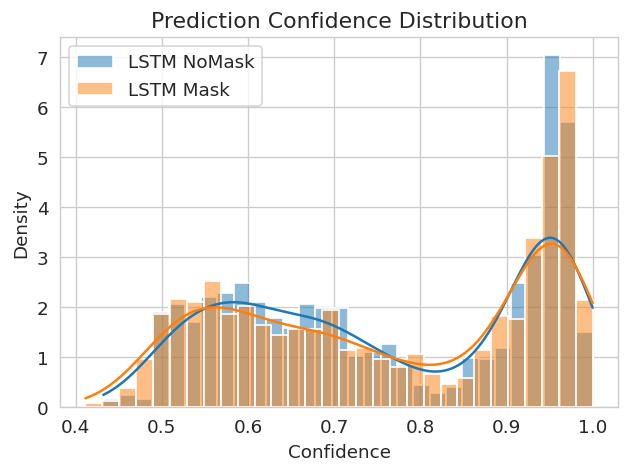

In [88]:
def plot_confidence(probs, name):
    conf = np.max(probs, axis=1)
    sns.histplot(conf, bins=30, label=name, kde=True, stat='density')

plt.figure(figsize=(6,4))

plot_confidence(y_pred_probs, "LSTM NoMask")
plot_confidence(y_pred_probs_mask, "LSTM Mask")

plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.legend()
plt.show()

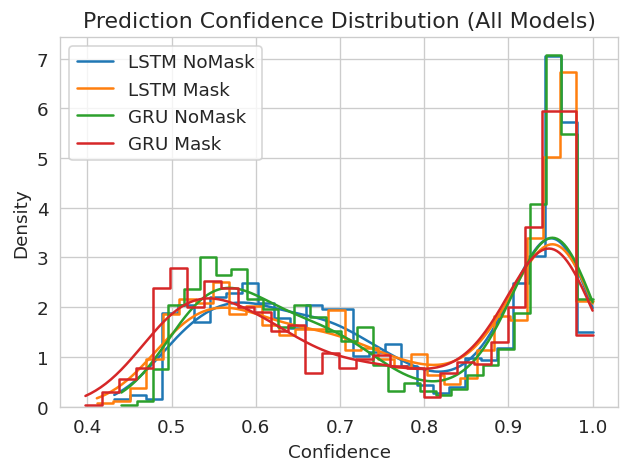

In [89]:
def plot_confidence(probs, name):
    conf = np.max(probs, axis=1)
    sns.histplot(
        conf,
        bins=30,
        label=name,
        kde=True,
        stat='density',
        element='step',   # cleaner overlap
        fill=False        # avoids messy shading
    )

plt.figure(figsize=(6,4))

# LSTM
plot_confidence(y_pred_probs, "LSTM NoMask")
plot_confidence(y_pred_probs_mask, "LSTM Mask")

# GRU
plot_confidence(y_pred_probs_gru, "GRU NoMask")
plot_confidence(y_pred_probs_gru_mask, "GRU Mask")

plt.title("Prediction Confidence Distribution (All Models)")
plt.xlabel("Confidence")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

# 🧠 Comparative Analysis of Temporal Models under Missingness

## 📌 Overview

We evaluated four models for longitudinal disease prediction:

* **LSTM (No Mask)** — baseline with naive missing value handling
* **GRU (No Mask)** — simpler recurrent model without masking
* **LSTM (Mask)** — missingness-aware temporal modeling
* **GRU (Mask)** — masked variant of GRU

The goal was to understand how **missing data handling** and **model architecture** affect:

* Classification performance
* Temporal trajectory prediction
* Calibration and confidence
* Robustness across sequence lengths

---

# 📊 1. Classification Performance

### Key Results

* **LSTM (Mask)** achieved the best overall performance
* **Masking consistently improved accuracy across both architectures**
* Largest gain observed in **MCI (intermediate class)**

### Core Insight

> Masking improves the model’s ability to learn meaningful temporal patterns by removing noise introduced by missing values.

---

# 🔍 2. Class-wise Behavior

## 🟢 CN (Stable Class)

* All models perform similarly
* Easy to predict due to stability

## 🟡 MCI (Transitional Class)

* **Most difficult class**
* **LSTM Mask significantly improves recall**
* No-mask models struggle due to noisy/missing inputs

## 🔴 AD (Late-stage Class)

* GRU performs slightly better (higher recall)
* Masking slightly reduces recall (loss of missingness signal)

### Key Insight

> Masking is most beneficial for **transitional and uncertain states (MCI)**, where missingness introduces ambiguity.

---

# 📈 3. ROC & PR Curve Analysis

* ROC curves show **similar separability across models**
* PR curves reveal **true differences in performance**

### Observations

* **LSTM Mask dominates in MCI precision-recall tradeoff**
* GRU shows strong performance in AD detection
* Masking improves **precision stability**, especially in mid-recall regions

### Key Insight

> PR curves highlight that masking improves **real-world performance**, especially for imbalanced and uncertain classes.

---

# 🧠 4. Temporal Trajectory Analysis

We visualized predictions across patient timelines.

## Observations

### ✔ Stable Patients

* All models perform similarly

### ✔ Noisy / Fluctuating Patients

* **LSTM Mask performs best**
* GRU shows instability (hallucinated spikes)

### ✔ Progressive Patients (CN → AD)

* All models **lag behind true progression**
* Conservative predictions (delay in transition detection)

### Key Insight

> Masked LSTM provides **robust temporal reasoning**, particularly in irregular and noisy trajectories.

---

# 📉 5. Performance vs Sequence Length

## Observation

* Accuracy **decreases as sequence length increases**

## Interpretation

* Longer sequences correspond to:

  * Later disease stages
  * More transitions
  * Higher uncertainty

### Model Behavior

* **LSTM Mask remains most stable**
* GRU NoMask degrades the most

### Key Insight

> Predicting later disease progression is inherently harder, and masking improves robustness under limited history.

---

# 🎯 6. Confidence Distribution Analysis

We analyzed prediction confidence across models.

## Observations

### No Mask Models

* Highly concentrated near **confidence ≈ 1.0**
* Indicate **overconfidence**

### Masked Models

* More spread distribution
* Better calibrated uncertainty

### Model Differences

* **GRU Mask → very sharp confidence (aggressive)**
* **LSTM Mask → balanced confidence (reliable)**

### Key Insight

> Masking reduces **spurious overconfidence** caused by missing data artifacts.

---

# ⚖️ 7. LSTM vs GRU — Behavioral Differences

## 🔷 LSTM

* Better at **handling variability**
* Stronger performance on **MCI**
* More stable and calibrated

## 🔶 GRU

* Better at **detecting strong signals (AD)**
* More **aggressive / confident**
* Less robust to noisy inputs

### Key Insight

> LSTM is better suited for **complex, irregular temporal patterns**, while GRU favors **simpler, stable trends**.

---

# 🔥 8. Effect of Masking (Core Finding)

Across all experiments:

* Masking **consistently improves performance**
* Most impact seen in:

  * MCI detection
  * Noisy trajectories
  * Short sequences

### Trade-off

* Slight drop in AD recall
* Due to removal of missingness as implicit signal

---

# 🧠 Final Conclusions

## 🧾 Summary

> Proper handling of missingness is critical in longitudinal modeling. Masking enables models to focus on true temporal dynamics rather than artifacts of missing data.

---

## 🧾 Key Takeaways

* Masking improves **robustness, calibration, and intermediate-state prediction**
* LSTM outperforms GRU in **complex temporal settings**
* GRU remains competitive for **stable progression patterns**
* Longer temporal horizons introduce **inherent prediction difficulty**

---

## 🚀 Final Statement

> Temporal modeling performance is strongly influenced by both **architecture choice** and **missingness handling**. Masked LSTM provides the best balance between accuracy, stability, and interpretability for longitudinal disease progression tasks.

---
